In [3]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
# Loading train, validation and test splits
X_train_df = pd.read_csv("Activity_PCAAll_Train.csv")
X_val_df   = pd.read_csv("Activity_PCAAll_Validation.csv")
X_test_df  = pd.read_csv("Activity_PCAAll_Test.csv")

X_train = X_train_df.drop(columns=["Activity"])
y_train = X_train_df["Activity"]

X_val   = X_val_df.drop(columns=["Activity"])
y_val   = X_val_df["Activity"]

X_test  = X_test_df.drop(columns=["Activity"])
y_test  = X_test_df["Activity"]

print("Dataset loaded successfully!")
print(f"Train size     : {X_train.shape}")
print(f"Validation size: {X_val.shape}")
print(f"Test size      : {X_test.shape}")
print(f"\nClasses: {y_train.unique()}")

Dataset loaded successfully!
Train size     : (6179, 561)
Validation size: (2060, 561)
Test size      : (2060, 561)

Classes: ['WALKING_UPSTAIRS' 'WALKING' 'SITTING' 'LAYING' 'WALKING_DOWNSTAIRS'
 'STANDING']


In [5]:
def print_metrics(y_true, y_pred, dataset_name="Test"):
    """
    Prints confusion matrix and classification metrics
    for multiclass classification.
    """
    cm       = confusion_matrix(y_true, y_pred)
    acc      = accuracy_score(y_true, y_pred)
    prec_mac = precision_score(y_true, y_pred, average='macro',  zero_division=0)
    prec_mic = precision_score(y_true, y_pred, average='micro',  zero_division=0)
    rec_mac  = recall_score(y_true, y_pred,    average='macro',  zero_division=0)
    rec_mic  = recall_score(y_true, y_pred,    average='micro',  zero_division=0)
    f1_mac   = f1_score(y_true, y_pred,        average='macro',  zero_division=0)
    f1_mic   = f1_score(y_true, y_pred,        average='micro',  zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {dataset_name} Results")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(cm)
    print(f"\nAccuracy          : {acc:.4f}")
    print(f"Precision (Macro) : {prec_mac:.4f}")
    print(f"Precision (Micro) : {prec_mic:.4f}")
    print(f"Recall    (Macro) : {rec_mac:.4f}")
    print(f"Recall    (Micro) : {rec_mic:.4f}")
    print(f"F1-Score  (Macro) : {f1_mac:.4f}")
    print(f"F1-Score  (Micro) : {f1_mic:.4f}")

    return acc

print("Helper function defined!")

Helper function defined!


In [6]:
print("Training Logistic Regression on PCA all-components data...")

logistic_reg = LogisticRegression(solver='liblinear', max_iter=1000)
logistic_reg.fit(X_train, y_train)

print("Done!")

y_val_pred_lr  = logistic_reg.predict(X_val)
y_test_pred_lr = logistic_reg.predict(X_test)

Training Logistic Regression on PCA all-components data...
Done!


In [7]:
print("=" * 55)
print("TASK 3.1: LOGISTIC REGRESSION - PCA ALL COMPONENTS")
print("=" * 55)

acc_lr_val  = print_metrics(y_val, y_val_pred_lr, "Validation")
acc_lr_test = print_metrics(y_test, y_test_pred_lr, "Test")

TASK 3.1: LOGISTIC REGRESSION - PCA ALL COMPONENTS

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 343  12   0   0   0]
 [  0  15 366   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9854
Precision (Macro) : 0.9862
Precision (Micro) : 0.9854
Recall    (Macro) : 0.9861
Recall    (Micro) : 0.9854
F1-Score  (Macro) : 0.9861
F1-Score  (Micro) : 0.9854

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 343  13   0   0   0]
 [  0  13 368   0   0   0]
 [  0   0   0 342   1   1]
 [  0   0   0   0 280   1]
 [  0   0   0   3   0 306]]

Accuracy          : 0.9845
Precision (Macro) : 0.9851
Precision (Micro) : 0.9845
Recall    (Macro) : 0.9850
Recall    (Micro) : 0.9845
F1-Score  (Macro) : 0.9851
F1-Score  (Micro) : 0.9845


In [8]:
print("Training SVM Linear on PCA all-components data... (may take a few minutes)")

linear_svm = SVC(kernel='linear', C=1.0)
linear_svm.fit(X_train, y_train)

print("Done!")

y_val_pred_lin  = linear_svm.predict(X_val)
y_test_pred_lin = linear_svm.predict(X_test)

Training SVM Linear on PCA all-components data... (may take a few minutes)
Done!


In [9]:
print("=" * 55)
print("TASK 3.2: SVM (LINEAR KERNEL) - PCA ALL COMPONENTS")
print("=" * 55)

acc_lin_val  = print_metrics(y_val, y_val_pred_lin, "Validation")
acc_lin_test = print_metrics(y_test, y_test_pred_lin, "Test")

TASK 3.2: SVM (LINEAR KERNEL) - PCA ALL COMPONENTS

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 341  13   0   0   1]
 [  0  22 359   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   1   0 308]]

Accuracy          : 0.9816
Precision (Macro) : 0.9826
Precision (Micro) : 0.9816
Recall    (Macro) : 0.9827
Recall    (Micro) : 0.9816
F1-Score  (Macro) : 0.9826
F1-Score  (Micro) : 0.9816

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 345  11   0   0   0]
 [  0  17 364   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 281   0]
 [  0   0   0   3   1 305]]

Accuracy          : 0.9845
Precision (Macro) : 0.9853
Precision (Micro) : 0.9845
Recall    (Macro) : 0.9853
Recall    (Micro) : 0.9845
F1-Score  (Macro) : 0.9852
F1-Score  (Micro) : 0.9845


In [10]:
# Task 1.3 - SVM with Polynomial Kernel

print("Training SVM with Polynomial Kernel for different degrees...")

best_degree  = None
best_val_acc = 0
degree_val_accuracies = {}

for degree in [2, 3, 4, 5]:
    poly_svm = SVC(kernel='poly', degree=degree, C=1.0, gamma='scale')
    poly_svm.fit(X_train, y_train)
    
    val_acc = poly_svm.score(X_val, y_val)
    degree_val_accuracies[degree] = val_acc
    print(f"Degree={degree}, Validation Accuracy={val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_degree  = degree

print(f"\nBest Degree: {best_degree} with Validation Accuracy: {best_val_acc:.4f}")

Training SVM with Polynomial Kernel for different degrees...
Degree=2, Validation Accuracy=0.9811
Degree=3, Validation Accuracy=0.9762
Degree=4, Validation Accuracy=0.9587
Degree=5, Validation Accuracy=0.9490

Best Degree: 2 with Validation Accuracy: 0.9811


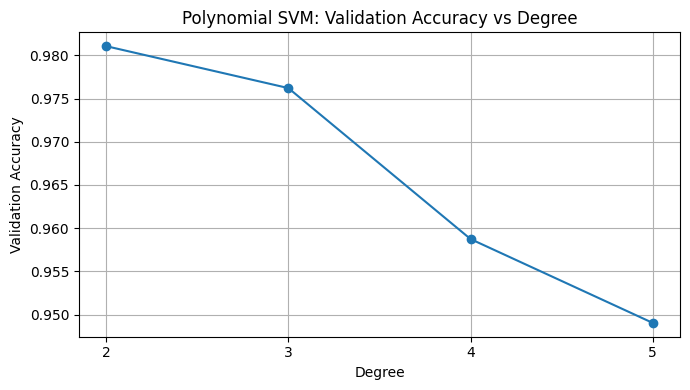

In [11]:
# plot validation accuracy vs degree
plt.figure(figsize=(7, 4))
plt.plot(list(degree_val_accuracies.keys()), list(degree_val_accuracies.values()), marker='o')
plt.title('Polynomial SVM: Validation Accuracy vs Degree')
plt.xlabel('Degree')
plt.ylabel('Validation Accuracy')
plt.xticks([2, 3, 4, 5])
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
# train again with the best degree and evaluate on test data
print(f"Training final Polynomial SVM with best degree = {best_degree}...")

best_poly_svm = SVC(kernel='poly', degree=best_degree, C=1.0, gamma='scale')
best_poly_svm.fit(X_train, y_train)

y_val_pred_poly  = best_poly_svm.predict(X_val)
y_test_pred_poly = best_poly_svm.predict(X_test)

print("Done!")

Training final Polynomial SVM with best degree = 2...
Done!


In [13]:
print("=" * 60)
print(f"TASK 3.3: SVM (POLY KERNEL, DEGREE={best_degree}) - PCA ALL COMPONENTS")
print("=" * 60)

print("\nValidation Accuracies for all degrees:")
for d, acc in degree_val_accuracies.items():
    marker = " <-- best" if d == best_degree else ""
    print(f"  Degree {d}: {acc:.4f}{marker}")

acc_poly_val  = print_metrics(y_val, y_val_pred_poly, "Validation (Best Degree)")
acc_poly_test = print_metrics(y_test, y_test_pred_poly, "Test (Best Degree)")

TASK 3.3: SVM (POLY KERNEL, DEGREE=2) - PCA ALL COMPONENTS

Validation Accuracies for all degrees:
  Degree 2: 0.9811 <-- best
  Degree 3: 0.9762
  Degree 4: 0.9587
  Degree 5: 0.9490

  Validation (Best Degree) Results
Confusion Matrix:
[[388   1   0   0   0   0]
 [  0 336  18   0   0   1]
 [  0  15 366   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 278   2]
 [  0   0   0   1   0 308]]

Accuracy          : 0.9811
Precision (Macro) : 0.9820
Precision (Micro) : 0.9811
Recall    (Macro) : 0.9818
Recall    (Micro) : 0.9811
F1-Score  (Macro) : 0.9819
F1-Score  (Micro) : 0.9811

  Test (Best Degree) Results
Confusion Matrix:
[[388   0   1   0   0   0]
 [  0 341  15   0   0   0]
 [  0  14 367   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 278   3]
 [  0   0   0   1   1 307]]

Accuracy          : 0.9830
Precision (Macro) : 0.9838
Precision (Micro) : 0.9830
Recall    (Macro) : 0.9836
Recall    (Micro) : 0.9830
F1-Score  (Macro) : 0.9837
F1-Score  (Micro) : 0.9830


In [14]:
# Task 1.4 - SVM with RBF Kernel
print("Training SVM with RBF (Gaussian) Kernel...")

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale')
rbf_svm.fit(X_train, y_train)

print("Done!")

y_val_pred_rbf  = rbf_svm.predict(X_val)
y_test_pred_rbf = rbf_svm.predict(X_test)

Training SVM with RBF (Gaussian) Kernel...
Done!


In [15]:
print("=" * 55)
print("TASK 3.4: SVM (RBF KERNEL) - PCA ALL COMPONENTS")
print("=" * 55)

acc_rbf_val  = print_metrics(y_val, y_val_pred_rbf, "Validation")
acc_rbf_test = print_metrics(y_test, y_test_pred_rbf, "Test")

TASK 3.4: SVM (RBF KERNEL) - PCA ALL COMPONENTS

  Validation Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 338  16   0   0   1]
 [  0  16 365   0   0   0]
 [  0   0   0 345   0   0]
 [  0   0   0   1 280   0]
 [  0   0   0   0   0 309]]

Accuracy          : 0.9835
Precision (Macro) : 0.9844
Precision (Micro) : 0.9835
Recall    (Macro) : 0.9844
Recall    (Micro) : 0.9835
F1-Score  (Macro) : 0.9844
F1-Score  (Micro) : 0.9835

  Test Results
Confusion Matrix:
[[389   0   0   0   0   0]
 [  0 345  11   0   0   0]
 [  0  14 367   0   0   0]
 [  0   0   0 344   0   0]
 [  0   0   0   0 280   1]
 [  0   0   0   2   0 307]]

Accuracy          : 0.9864
Precision (Macro) : 0.9871
Precision (Micro) : 0.9864
Recall    (Macro) : 0.9871
Recall    (Micro) : 0.9864
F1-Score  (Macro) : 0.9871
F1-Score  (Micro) : 0.9864


In [16]:
# Task 1.5 - Comparison table for all classifiers on original data

comparison_val = {
    'Classifier':          ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Validation Accuracy': [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
}

comparison_test = {
    'Classifier':      ['Logistic Regression', 'SVM Linear', f'SVM Poly (d={best_degree})', 'SVM RBF'],
    'Test Accuracy':   [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]
}

df_val  = pd.DataFrame(comparison_val)
df_test = pd.DataFrame(comparison_test)

print("Validation Accuracy Comparison (Original Data):")
print(df_val.to_string(index=False))

print("\nTest Accuracy Comparison (Original Data):")
print(df_test.to_string(index=False))

Validation Accuracy Comparison (Original Data):
         Classifier  Validation Accuracy
Logistic Regression             0.985437
         SVM Linear             0.981553
     SVM Poly (d=2)             0.981068
            SVM RBF             0.983495

Test Accuracy Comparison (Original Data):
         Classifier  Test Accuracy
Logistic Regression       0.984466
         SVM Linear       0.984466
     SVM Poly (d=2)       0.983010
            SVM RBF       0.986408


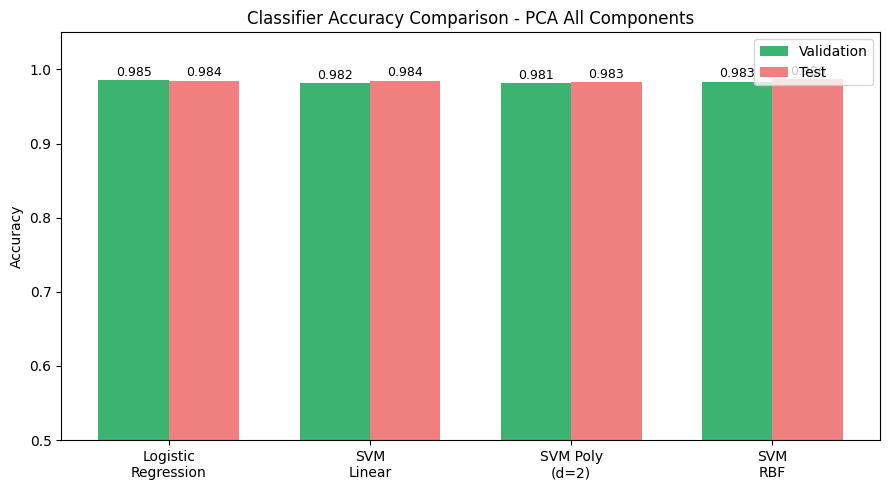


Discussion:
Best classifier on Validation: Logistic Regression (0.9854)
Best classifier on Test:       SVM RBF (0.9864)


In [19]:
classifiers = ['Logistic\nRegression', 'SVM\nLinear', f'SVM Poly\n(d={best_degree})', 'SVM\nRBF']
val_accs  = [acc_lr_val, acc_lin_val, acc_poly_val, acc_rbf_val]
test_accs = [acc_lr_test, acc_lin_test, acc_poly_test, acc_rbf_test]

x = np.arange(len(classifiers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, val_accs,  width, label='Validation', color='mediumseagreen')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test', color='lightcoral')

ax.set_title('Classifier Accuracy Comparison - PCA All Components')
ax.set_ylabel('Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(classifiers)
ax.legend()
ax.set_ylim(0.5, 1.05)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_val_clf  = classifiers[np.argmax(val_accs)].replace('\n', ' ')
best_test_clf = classifiers[np.argmax(test_accs)].replace('\n', ' ')
print(f"\nDiscussion:")
print(f"Best classifier on Validation: {best_val_clf} ({max(val_accs):.4f})")
print(f"Best classifier on Test:       {best_test_clf} ({max(test_accs):.4f})")